# Data Science with Python Internship – Task 3
## Titanic Dataset: Mini Exploratory Data Analysis (EDA)

**Maincrafts Technology**

A deeper mini-EDA on the Titanic dataset — cleaning, feature engineering
(Age Group, Family Size), and analyzing survival patterns by age group,
port of embarkation, and family size.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Titanic Dataset

Column names are standardized to the common Kaggle Titanic convention.


In [2]:
df = pd.read_csv("titanic.csv")

df = df.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
    "class": "Class",
    "who": "Who",
    "adult_male": "Adult_Male",
    "deck": "Deck",
    "embark_town": "Embark_Town",
    "alive": "Alive",
    "alone": "Alone",
})

print("Shape:", df.shape)
df.head()


Shape: (891, 15)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Class,Who,Adult_Male,Deck,Embark_Town,Alive,Alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    str    
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Embarked     889 non-null    str    
 8   Class        891 non-null    str    
 9   Who          891 non-null    str    
 10  Adult_Male   891 non-null    bool   
 11  Deck         203 non-null    str    
 12  Embark_Town  889 non-null    str    
 13  Alive        891 non-null    str    
 14  Alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## 3. Data Cleaning

In [4]:
df.isnull().sum().sort_values(ascending=False)


Deck           688
Age            177
Embarked         2
Embark_Town      2
Sex              0
Pclass           0
Survived         0
Fare             0
Parch            0
SibSp            0
Class            0
Adult_Male       0
Who              0
Alive            0
Alone            0
dtype: int64

In [5]:
# Age: fill missing values with the mean age
mean_age = df["Age"].mean()
df["Age"] = df["Age"].fillna(mean_age)

# Embarked: fill the (very few) missing values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin/Deck has too many missing values to be usable — drop it
df = df.drop(columns=["Deck"])

df.isnull().sum().sort_values(ascending=False)


Embark_Town    2
Survived       0
Sex            0
Age            0
SibSp          0
Pclass         0
Parch          0
Fare           0
Class          0
Embarked       0
Who            0
Adult_Male     0
Alive          0
Alone          0
dtype: int64

## 4. Feature Engineering

Create two new features:
- **AgeGroup** — bucket passengers into Child / Teen / Adult / Senior
- **FamilySize** — total family members aboard (`SibSp` + `Parch` + 1 for the
  passenger themselves)


In [6]:
bins = [0, 12, 19, 59, 100]
labels = ["Child (0-12)", "Teen (13-19)", "Adult (20-59)", "Senior (60+)"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["Age", "AgeGroup", "SibSp", "Parch", "FamilySize"]].head()


,Age,AgeGroup,SibSp,Parch,FamilySize
0,22.0,Adult (20-59),1,0,2
1,38.0,Adult (20-59),1,0,2
2,26.0,Adult (20-59),0,0,1
3,35.0,Adult (20-59),1,0,2
4,35.0,Adult (20-59),0,0,1


## 5. Survival Analysis

### 5.1 Survival Rate by Age Group


In [7]:
survival_by_age = df.groupby("AgeGroup", observed=True)["Survived"].mean() * 100
print(survival_by_age.round(2))


AgeGroup
Child (0-12)     57.97
Teen (13-19)     41.05
Adult (20-59)    36.52
Senior (60+)     26.92
Name: Survived, dtype: float64


**Insight:** Children had the highest survival rate of any age group,
consistent with the "women and children first" evacuation priority.


### 5.2 Survival Rate by Port of Embarkation

In [8]:
survival_by_port = df.groupby("Embark_Town")["Survived"].mean() * 100
print(survival_by_port.round(2))


Embark_Town
Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: Survived, dtype: float64


**Insight:** Passengers who boarded at Cherbourg had a notably higher
survival rate than those from Southampton or Queenstown — likely linked to
class composition, since Cherbourg had a higher proportion of 1st class
passengers.


### 5.3 Survival Rate by Family Size

In [9]:
survival_by_family = df.groupby("FamilySize")["Survived"].mean() * 100
print(survival_by_family.round(2))


FamilySize
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64


**Insight:** Passengers traveling with a small family (2-4 members) had
better survival odds than those traveling completely alone or with a very
large family — small groups could help each other, while large families
struggled to stay together and evacuate quickly.


## 6. Visualizations

### 6.1 Histogram of Passenger Ages


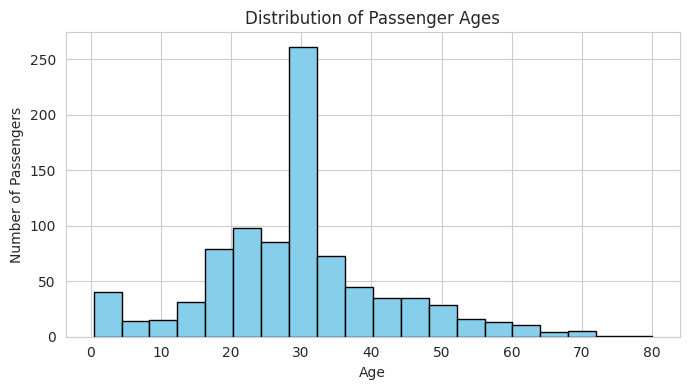

In [10]:
plt.figure(figsize=(7, 4))
df["Age"].plot(kind="hist", bins=20, edgecolor="black", color="skyblue")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("age_histogram_task3.png", dpi=150)
plt.show()


### 6.2 Correlation Heatmap

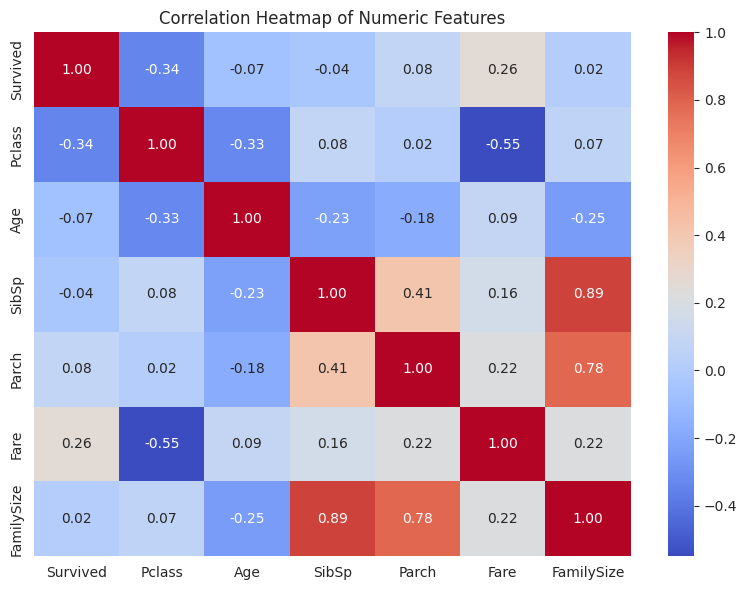

In [11]:
plt.figure(figsize=(8, 6))
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


### 6.3 Survival Rate by Family Size

/tmp/ipykernel_91/768074570.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="FamilySize", y="Survived", data=df, palette="Set2")


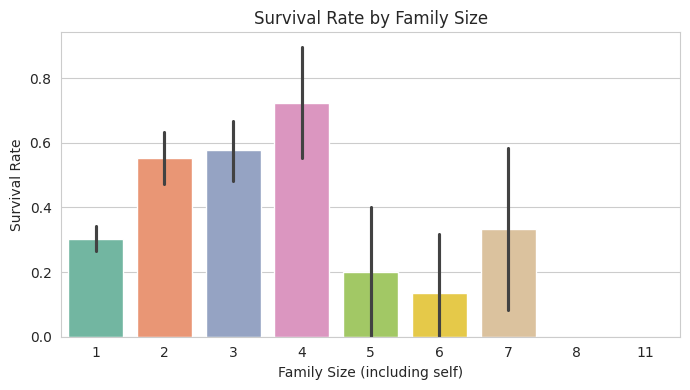

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(x="FamilySize", y="Survived", data=df, palette="Set2")
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size (including self)")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("survival_by_family_size.png", dpi=150)
plt.show()


## 7. Summary of Insights

- **Age Group:** Children survived at the highest rate, adults and seniors
  fared worse — matching known evacuation priorities.
- **Port of Embarkation:** Cherbourg passengers had the highest survival
  rate, likely tied to a higher share of 1st class travelers boarding there.
- **Family Size:** Small families (2-4 members) survived more often than solo
  travelers or very large families — a "sweet spot" for mutual help without
  the logistical difficulty of evacuating a large group.
- **Correlations:** `Pclass` and `Fare` show the strongest (negative/positive)
  correlation with `Survived` among numeric features, reinforcing that
  socioeconomic status was a major factor in survival.
